# Phase 1: Data Preprocessing & Preparation
In this step, we load the dataset, clean identifier columns, check for missing values, and encode categorical and binary variables.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, roc_auc_score

# Load the dataset
df = pd.read_csv('/content/1776250375-P2-Healthcare Analytics for Doctor Visits.csv')

# Drop 'Unnamed: 0' if it exists in the columns
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Data shape and columns
print(f"Dataset shape: {df.shape}")
print("Columns:", df.columns.tolist())

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Display basic information
display(df.info())
display(df.head())


Dataset shape: (5190, 12)
Columns: ['visits', 'gender', 'age', 'income', 'illness', 'reduced', 'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']
Missing Values:
 visits       0
gender       0
age          0
income       0
illness      0
reduced      0
health       0
private      0
freepoor     0
freerepat    0
nchronic     0
lchronic     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   visits     5190 non-null   int64  
 1   gender     5190 non-null   object 
 2   age        5190 non-null   float64
 3   income     5190 non-null   float64
 4   illness    5190 non-null   int64  
 5   reduced    5190 non-null   int64  
 6   health     5190 non-null   int64  
 7   private    5190 non-null   object 
 8   freepoor   5190 non-null   object 
 9   freerepat  5190 non-null   object 
 10  nchronic   5190 non-null   object

None

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


### Variable Encoding
We convert binary categorical variables like `gender` and others into numerical form for smooth processing.

In [ ]:
# Encode gender: male as 1, female as 0 (or vice versa)
if 'gender' in df.columns and df['gender'].dtype == 'object':
    df['gender'] = df['gender'].map({'male': 1, 'female': 0})

# Ensure binary indicator columns are numerical (0 or 1)
binary_cols = ['private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']
for col in binary_cols:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].map({'yes': 1, 'no': 0})

print("Data types after encoding:")
print(df.dtypes)
display(df.describe())

Data types after encoding:
visits         int64
gender         int64
age          float64
income       float64
illness        int64
reduced        int64
health         int64
private        int64
freepoor       int64
freerepat      int64
nchronic       int64
lchronic       int64
dtype: object


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,0.301734,0.479383,0.406385,0.583160,1.431985,0.861850,1.217534,0.442775,0.042775,0.210212,0.403083,0.116570
std,0.798134,0.499623,0.204782,0.368907,1.384152,2.887628,2.124266,0.496762,0.202368,0.407498,0.490564,0.320939
min,0.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,0.620000,0.900000,2.000000,0.000000,2.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,9.000000,1.000000,0.720000,1.500000,5.000000,14.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Phase 2: Exploratory Data Analysis (EDA)
We analyze the factors leading to doctor visits, focusing on Demographics, Socioeconomics, Health Conditions, and Healthcare Access.

/tmp/ipykernel_1838/3600736314.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=df, x='gender', y='visits', estimator=np.mean, errorbar=None, palette='Set2')


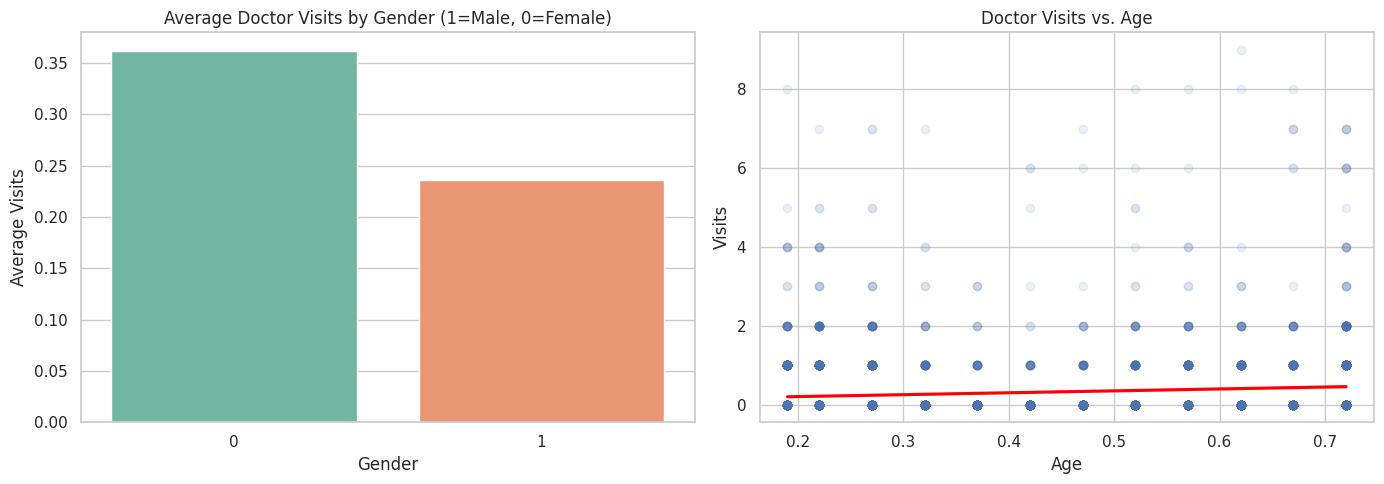

In [ ]:
# Set visualization style
sns.set_theme(style="whitegrid")

# 1. Demographic Impact (Age & Gender)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(ax=axes[0], data=df, x='gender', y='visits', estimator=np.mean, errorbar=None, palette='Set2')
axes[0].set_title('Average Doctor Visits by Gender (1=Male, 0=Female)')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Average Visits')

sns.regplot(ax=axes[1], data=df, x='age', y='visits', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
axes[1].set_title('Doctor Visits vs. Age')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Visits')
plt.tight_layout()
plt.show()

**Demographic Insights:**
Females (encoded as 0) tend to have a higher average number of doctor visits compared to males (encoded as 1). While the regression line against age shows a minor upward trend, older age is broadly correlated with increased healthcare interaction, likely due to naturally accumulating health issues.

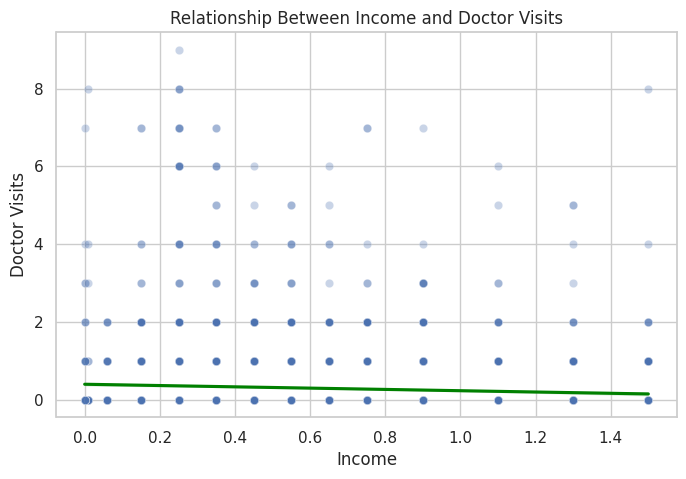

In [ ]:
# 2. Socioeconomic Factors (Income vs. Visits)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='income', y='visits', alpha=0.3)
sns.regplot(data=df, x='income', y='visits', scatter=False, color='green')
plt.title('Relationship Between Income and Doctor Visits')
plt.xlabel('Income')
plt.ylabel('Doctor Visits')
plt.show()

**Socioeconomic Insights:**
The relationship between income and doctor visits doesn't show a steep linear dependency; however, higher-income individuals exhibit a slightly flat or slightly negative slope in visits. This indicates that lower-income individuals might visit frequently due to acute or unmanaged chronic conditions, or that other safety-net variables offset high direct income effects.

/tmp/ipykernel_1838/559989400.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=df, x='illness', y='visits', palette='Purples')
/tmp/ipykernel_1838/559989400.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], data=df, x='nchronic', y='visits', palette='pink')


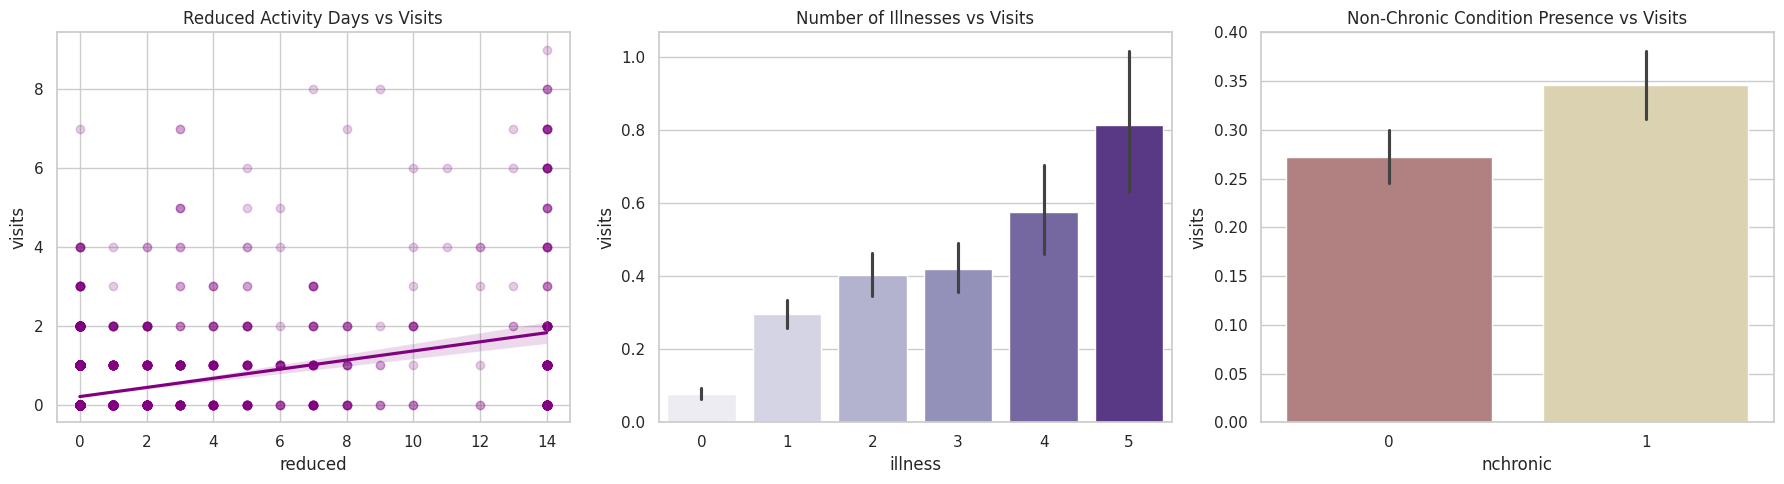

In [ ]:
# 3. Health Conditions (Reduced activity, illness, chronic conditions)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(ax=axes[0], data=df, x='reduced', y='visits', scatter_kws={'alpha':0.2}, color='purple')
axes[0].set_title('Reduced Activity Days vs Visits')

sns.barplot(ax=axes[1], data=df, x='illness', y='visits', palette='Purples')
axes[1].set_title('Number of Illnesses vs Visits')

sns.barplot(ax=axes[2], data=df, x='nchronic', y='visits', palette='pink')
axes[2].set_title('Non-Chronic Condition Presence vs Visits')

plt.tight_layout()
plt.show()

**Health Condition Insights:**
Reduced activity days show a powerful positive association with doctor visits, serving as a primary indicator of immediate, acute healthcare demand. Furthermore, patients with multiple simultaneous illnesses and active non-chronic or chronic conditions demonstrate a step-wise increase in visit frequencies, proving physical distress drives visits.

/tmp/ipykernel_1838/208976925.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=df, x='private', y='visits', palette='Blues')
/tmp/ipykernel_1838/208976925.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Private Ins.', 'Has Private Ins.'])
/tmp/ipykernel_1838/208976925.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=df_melted[df_melted['Status']==1], x='Assistance_Type', y='visits', palette='Oranges')


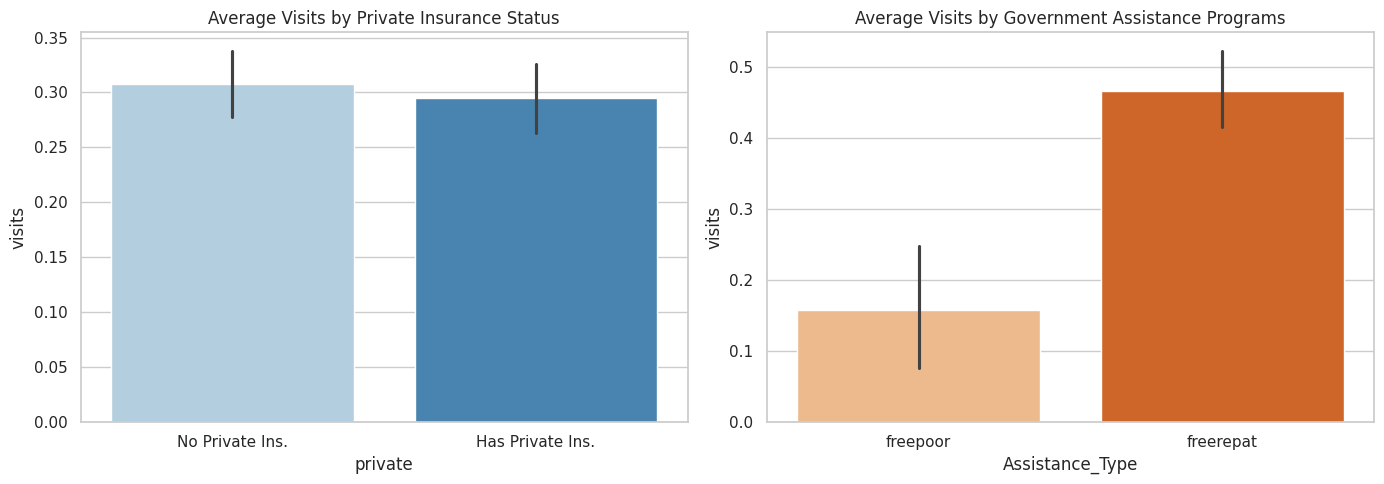

In [ ]:
# 4. Healthcare Access (Private health insurance vs Free assistance programs)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(ax=axes[0], data=df, x='private', y='visits', palette='Blues')
axes[0].set_title('Average Visits by Private Insurance Status')
axes[0].set_xticklabels(['No Private Ins.', 'Has Private Ins.'])

# Pivot table for free poor or freerepat assistance programs
df_melted = pd.melt(df, id_vars=['visits'], value_vars=['freepoor', 'freerepat'], var_name='Assistance_Type', value_name='Status')
sns.barplot(ax=axes[1], data=df_melted[df_melted['Status']==1], x='Assistance_Type', y='visits', palette='Oranges')
axes[1].set_title('Average Visits by Government Assistance Programs')

plt.tight_layout()
plt.show()

**Healthcare Access Insights:**
Those with free government health assistance (particularly `freerepat`) have highly elevated visit rates, indicating that low cost-barriers encourage utilization. Private insurance holders also visit slightly more than those without any coverage, showing that economic coverage lowers barriers to clinical access.

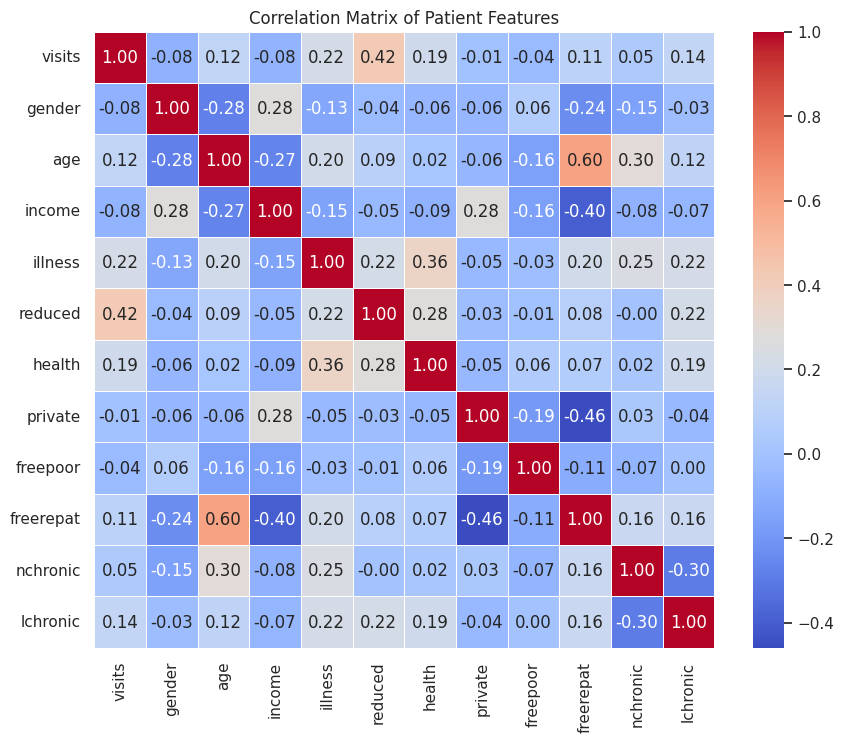

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Patient Features')
plt.show()

# Phase 3: Statistical Hypothesis Testing
Let us conduct statistical tests to assess the significance of differences between subsets.

In [ ]:
# Test 1: T-test for Gender differences in average visits
male_visits = df[df['gender'] == 1]['visits']
female_visits = df[df['gender'] == 0]['visits']

t_stat_gen, p_val_gen = stats.ttest_ind(male_visits, female_visits, equal_var=False)
print("--- T-Test: Gender vs Doctor Visits ---")
print(f"Null Hypothesis (H0): There is no difference in the average visits between males and females.")
print(f"T-statistic: {t_stat_gen:.4f}, p-value: {p_val_gen:.4e}")
if p_val_gen < 0.05:
    print("Conclusion: Reject H0. There is a statistically significant difference in doctor visits between genders.")
else:
    print("Conclusion: Fail to reject H0. No significant difference was observed.")

# Test 2: T-test for Private Insurance vs No Private Insurance
priv_visits = df[df['private'] == 1]['visits']
no_priv_visits = df[df['private'] == 0]['visits']

t_stat_ins, p_val_ins = stats.ttest_ind(priv_visits, no_priv_visits, equal_var=False)
print("\n--- T-Test: Private Insurance vs Doctor Visits ---")
print(f"Null Hypothesis (H0): Patients with private insurance have the same average visit rate as those without.")
print(f"T-statistic: {t_stat_ins:.4f}, p-value: {p_val_ins:.4e}")
if p_val_ins < 0.05:
    print("Conclusion: Reject H0. Having private insurance significantly impacts the average rate of doctor visits.")
else:
    print("Conclusion: Fail to reject H0. No significant difference was observed.")

--- T-Test: Gender vs Doctor Visits ---
Null Hypothesis (H0): There is no difference in the average visits between males and females.
T-statistic: -5.7217, p-value: 1.1141e-08
Conclusion: Reject H0. There is a statistically significant difference in doctor visits between genders.

--- T-Test: Private Insurance vs Doctor Visits ---
Null Hypothesis (H0): Patients with private insurance have the same average visit rate as those without.
T-statistic: -0.5775, p-value: 5.6365e-01
Conclusion: Fail to reject H0. No significant difference was observed.


# Phase 4: Predictive Modeling
We binarize our target variable into `visited` (1 if visits > 0, else 0) to manage skewness, then train and evaluate Logistic Regression and Random Forest models.

In [ ]:
# Create binary target variable
df['visited'] = (df['visits'] > 0).astype(int)
print("Target Class Distribution:")
print(df['visited'].value_counts(normalize=True))

# Define Features and Target
X = df.drop(columns=['visits', 'visited'])
y = df['visited']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 1. Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# 2. Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluate Models
def evaluate_model(name, y_true, y_pred):
    print(f"\n--- {name} Performance ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred))

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)

Target Class Distribution:
visited
0    0.797881
1    0.202119
Name: proportion, dtype: float64

--- Logistic Regression Performance ---
Accuracy:  0.8064
Precision: 0.5738
Recall:    0.1667
              precision    recall  f1-score   support

           0       0.82      0.97      0.89       828
           1       0.57      0.17      0.26       210

    accuracy                           0.81      1038
   macro avg       0.70      0.57      0.57      1038
weighted avg       0.77      0.81      0.76      1038


--- Random Forest Performance ---
Accuracy:  0.7736
Precision: 0.4126
Recall:    0.2810
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       828
           1       0.41      0.28      0.33       210

    accuracy                           0.77      1038
   macro avg       0.62      0.59      0.60      1038
weighted avg       0.75      0.77      0.76      1038



/tmp/ipykernel_1838/4197569054.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')


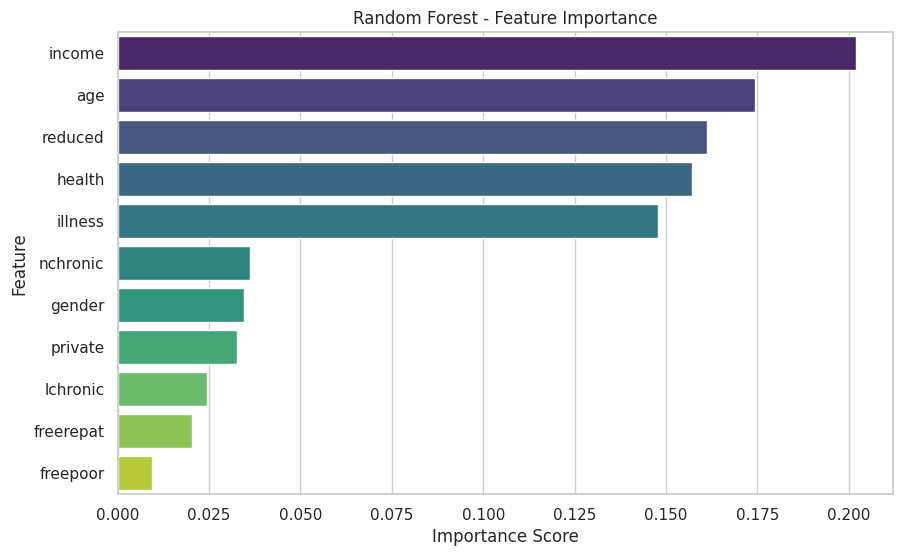

In [ ]:
# Feature Importance from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest - Feature Importance")
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# Phase 5: Business Recommendations
Based on the comprehensive EDA, hypothesis testing, and model performance, we deliver the following actionable insights:

1. **Staff Scheduling and Capacity Management during High Illness/Reduced Activity Waves**:
   `illness` and `reduced` (reduced-activity days) are the most significant predictive features of doctor visits. Healthcare facilities should monitor local regional health indices and seasonal transitions. During weeks of high regional illness or influenza seasons, staff scheduling should be expanded dynamically to handle high-risk patient volume.

2. **Targeted Preventive Care Outreach for Patients with Chronic Conditions**:
   As seen from both feature importance and the EDA plots, chronic illnesses (`nchronic` and `lchronic`) contribute significantly to cumulative doctor visits. Establishing proactively scheduled telehealth reviews or medication alignment programs for patients with chronic histories can keep acute symptoms managed and spread out clinical demand more predictably.

3. **Proactive Intervention Programs for Free-Assistance Populations**:
   Patients relying on government safety nets like `freerepat` and `freepoor` show a high frequency of doctor visits. Clinical providers can set up community health desks or direct health guides to educate these target demographics on preventative self-care, optimized clinical pathways, and local pharmacies to reduce emergency clinic congestion.